In [152]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jockeroika/life-style-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'life-style-data' dataset.
Path to dataset files: /kaggle/input/life-style-data


In [197]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report


import pickle

In [154]:
import os

print(f"Contents of the dataset directory: {path}")
print("------------------------------------")
for root, dirs, files in os.walk(path):
    for f in files:
        print(os.path.join(root, f))
    for d in dirs:
        print(os.path.join(root, d) + "/")
print("------------------------------------")

df = pd.read_csv(path + "/Final_data.csv")

df.head()


Contents of the dataset directory: /kaggle/input/life-style-data
------------------------------------
/kaggle/input/life-style-data/Final_data.csv
/kaggle/input/life-style-data/meal_metadata.csv
------------------------------------


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin
0,34.91,Male,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,Strength,...,2139.59,0.500432,1.624789,0.741237,0.835985,725.10,47.777394,685.1600,7.260425e+19,Medium
1,23.37,Female,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,HIIT,...,1711.65,0.500850,1.514093,0.551247,0.734270,-232.91,40.809803,978.6184,1.020506e+20,High
2,33.20,Female,58.98,1.67,175.04,123.95,54.96,0.91,802.26,Cardio,...,1965.92,0.500610,1.663445,0.574534,0.708124,805.74,44.635580,654.5266,1.079607e+20,High
3,38.69,Female,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,HIIT,...,1627.28,0.499533,0.862017,0.744155,0.811150,1206.21,63.007432,773.6300,8.987921e+19,High
4,45.09,Male,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,Strength,...,2659.23,0.500581,2.538153,0.668405,0.789751,303.60,43.347504,711.4176,5.264685e+19,Low


In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 54 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             20000 non-null  float64
 1   Gender                          20000 non-null  object 
 2   Weight (kg)                     20000 non-null  float64
 3   Height (m)                      20000 non-null  float64
 4   Max_BPM                         20000 non-null  float64
 5   Avg_BPM                         20000 non-null  float64
 6   Resting_BPM                     20000 non-null  float64
 7   Session_Duration (hours)        20000 non-null  float64
 8   Calories_Burned                 20000 non-null  float64
 9   Workout_Type                    20000 non-null  object 
 10  Fat_Percentage                  20000 non-null  float64
 11  Water_Intake (liters)           20000 non-null  float64
 12  Workout_Frequency (days/week)   

In [156]:
df.isnull().sum()

,0
Age,0
Gender,0
Weight (kg),0
Height (m),0
Max_BPM,0
Avg_BPM,0
Resting_BPM,0
Session_Duration (hours),0
Calories_Burned,0
Workout_Type,0


In [157]:
df.duplicated().sum()

np.int64(0)

In [158]:
df['Gender'] = df['Gender'].replace({'Male':1 , 'Female':0}).astype(int)


/tmp/ipython-input-700108803.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender'] = df['Gender'].replace({'Male':1 , 'Female':0}).astype(int)


In [159]:
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin
0,34.91,1,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,Strength,...,2139.59,0.500432,1.624789,0.741237,0.835985,725.10,47.777394,685.1600,7.260425e+19,Medium
1,23.37,0,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,HIIT,...,1711.65,0.500850,1.514093,0.551247,0.734270,-232.91,40.809803,978.6184,1.020506e+20,High
2,33.20,0,58.98,1.67,175.04,123.95,54.96,0.91,802.26,Cardio,...,1965.92,0.500610,1.663445,0.574534,0.708124,805.74,44.635580,654.5266,1.079607e+20,High
3,38.69,0,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,HIIT,...,1627.28,0.499533,0.862017,0.744155,0.811150,1206.21,63.007432,773.6300,8.987921e+19,High
4,45.09,1,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,Strength,...,2659.23,0.500581,2.538153,0.668405,0.789751,303.60,43.347504,711.4176,5.264685e+19,Low


In [160]:
df = pd.get_dummies(df, columns=['Workout_Type'] , dtype=int)
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,...,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin,Workout_Type_Cardio,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga
0,34.91,1,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,26.800377,...,0.835985,725.10,47.777394,685.1600,7.260425e+19,Medium,0,0,1,0
1,23.37,0,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,27.655021,...,0.734270,-232.91,40.809803,978.6184,1.020506e+20,High,0,1,0,0
2,33.20,0,58.98,1.67,175.04,123.95,54.96,0.91,802.26,24.320821,...,0.708124,805.74,44.635580,654.5266,1.079607e+20,High,1,0,0,0
3,38.69,0,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,32.813572,...,0.811150,1206.21,63.007432,773.6300,8.987921e+19,High,0,1,0,0
4,45.09,1,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,17.307319,...,0.789751,303.60,43.347504,711.4176,5.264685e+19,Low,0,0,1,0


In [161]:
df.drop(columns=['meal_name'], axis=1 , inplace=True)

In [162]:

df['meal_type'].value_counts()
df = pd.get_dummies(df , columns=['meal_type'] , dtype=int)
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,...,Burns Calories (per 30 min)_bc,Burns_Calories_Bin,Workout_Type_Cardio,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga,meal_type_Breakfast,meal_type_Dinner,meal_type_Lunch,meal_type_Snack
0,34.91,1,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,26.800377,...,7.260425e+19,Medium,0,0,1,0,0,0,1,0
1,23.37,0,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,27.655021,...,1.020506e+20,High,0,1,0,0,0,0,1,0
2,33.20,0,58.98,1.67,175.04,123.95,54.96,0.91,802.26,24.320821,...,1.079607e+20,High,1,0,0,0,1,0,0,0
3,38.69,0,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,32.813572,...,8.987921e+19,High,0,1,0,0,0,0,1,0
4,45.09,1,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,17.307319,...,5.264685e+19,Low,0,0,1,0,1,0,0,0


In [163]:
df['diet_type'].value_counts()
df = pd.get_dummies(df , columns=['diet_type'] , dtype=int)
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,...,meal_type_Breakfast,meal_type_Dinner,meal_type_Lunch,meal_type_Snack,diet_type_Balanced,diet_type_Keto,diet_type_Low-Carb,diet_type_Paleo,diet_type_Vegan,diet_type_Vegetarian
0,34.91,1,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,26.800377,...,0,0,1,0,0,0,0,0,1,0
1,23.37,0,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,27.655021,...,0,0,1,0,0,0,0,0,0,1
2,33.20,0,58.98,1.67,175.04,123.95,54.96,0.91,802.26,24.320821,...,1,0,0,0,0,0,0,1,0,0
3,38.69,0,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,32.813572,...,0,0,1,0,0,0,0,1,0,0
4,45.09,1,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,17.307319,...,1,0,0,0,0,0,0,0,1,0


In [164]:

df['cooking_method'].value_counts()
df = pd.get_dummies(df , columns=['cooking_method'] , dtype=int)
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,...,diet_type_Paleo,diet_type_Vegan,diet_type_Vegetarian,cooking_method_Baked,cooking_method_Boiled,cooking_method_Fried,cooking_method_Grilled,cooking_method_Raw,cooking_method_Roasted,cooking_method_Steamed
0,34.91,1,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,26.800377,...,0,1,0,0,0,0,1,0,0,0
1,23.37,0,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,27.655021,...,0,0,1,0,0,1,0,0,0,0
2,33.20,0,58.98,1.67,175.04,123.95,54.96,0.91,802.26,24.320821,...,1,0,0,0,1,0,0,0,0,0
3,38.69,0,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,32.813572,...,1,0,0,0,0,1,0,0,0,0
4,45.09,1,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,17.307319,...,0,1,0,1,0,0,0,0,0,0


In [165]:
df['Name of Exercise'].value_counts()
df = pd.get_dummies(df , columns=['Name of Exercise'] , dtype=int)
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,...,Name of Exercise_Squats,Name of Exercise_Step-ups,Name of Exercise_Superman,Name of Exercise_Thrusters,Name of Exercise_Tricep Dips,Name of Exercise_Tricep Extensions,Name of Exercise_Turkish Get-ups,Name of Exercise_Wall Angels,Name of Exercise_Windshield Wipers,Name of Exercise_Zottman Curls
0,34.91,1,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,26.800377,...,0,0,0,0,0,0,0,0,0,0
1,23.37,0,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,27.655021,...,0,0,0,0,0,0,0,0,0,0
2,33.20,0,58.98,1.67,175.04,123.95,54.96,0.91,802.26,24.320821,...,0,0,0,0,0,0,0,0,0,0
3,38.69,0,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,32.813572,...,0,0,0,0,0,0,0,0,0,0
4,45.09,1,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,17.307319,...,0,0,0,0,0,0,0,0,0,0


In [166]:
df['Benefit'].value_counts()
df = pd.get_dummies(df , columns=['Benefit'],dtype=int)
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,...,Benefit_Strengthens lower abs and hip flexors,Benefit_Strengthens lower body,Benefit_Strengthens shoulders,Benefit_Strengthens triceps and chest,Benefit_Targets abdominal muscles,Benefit_Targets biceps and forearms,Benefit_Targets lower abs,Benefit_Targets lower chest,Benefit_Targets obliques and improves core rotation,Benefit_Targets upper chest
0,34.91,1,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,26.800377,...,0,0,0,0,0,0,0,0,0,0
1,23.37,0,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,27.655021,...,0,0,0,0,0,0,0,0,0,0
2,33.20,0,58.98,1.67,175.04,123.95,54.96,0.91,802.26,24.320821,...,0,0,0,0,0,0,0,0,0,0
3,38.69,0,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,32.813572,...,0,0,0,0,0,0,0,0,0,0
4,45.09,1,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,17.307319,...,0,0,0,0,0,0,0,0,1,0


In [167]:
df['Target Muscle Group'].value_counts()
df = pd.get_dummies(df , columns=['Target Muscle Group'] , dtype=int)
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,...,"Target Muscle Group_Quadriceps, Glutes","Target Muscle Group_Quadriceps, Hamstrings, Glutes","Target Muscle Group_Rear Deltoids, Upper Back",Target Muscle Group_Shoulders,"Target Muscle Group_Shoulders, Triceps","Target Muscle Group_Shoulders, Upper Back",Target Muscle Group_Triceps,"Target Muscle Group_Triceps, Chest","Target Muscle Group_Upper Back, Rear Deltoids","Target Muscle Group_Upper Chest, Triceps"
0,34.91,1,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,26.800377,...,0,0,0,0,1,0,0,0,0,0
1,23.37,0,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,27.655021,...,0,0,0,0,0,0,0,0,0,0
2,33.20,0,58.98,1.67,175.04,123.95,54.96,0.91,802.26,24.320821,...,1,0,0,0,0,0,0,0,0,0
3,38.69,0,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,32.813572,...,0,0,0,0,0,0,0,0,0,0
4,45.09,1,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,17.307319,...,0,0,0,0,0,0,0,0,0,0


In [168]:
df['Equipment Needed'].value_counts()
df = pd.get_dummies(df , columns=['Equipment Needed'] , dtype=int)
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,...,Equipment Needed_Kettlebell,Equipment Needed_Low Bar or TRX,Equipment Needed_None or Dumbbell,Equipment Needed_None or Dumbbells,Equipment Needed_Parallel Bars or Chair,Equipment Needed_Pull-up Bar,Equipment Needed_Resistance Band,Equipment Needed_Resistance Band or Cable Machine,Equipment Needed_Step or Box,Equipment Needed_Wall
0,34.91,1,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,26.800377,...,0,0,0,0,0,0,0,0,0,0
1,23.37,0,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,27.655021,...,0,0,0,0,0,0,0,0,1,0
2,33.20,0,58.98,1.67,175.04,123.95,54.96,0.91,802.26,24.320821,...,0,0,0,0,0,0,0,0,1,0
3,38.69,0,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,32.813572,...,0,0,0,0,1,0,0,0,0,0
4,45.09,1,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,17.307319,...,0,0,0,0,0,0,0,0,0,1


In [169]:
df['Difficulty Level'].value_counts()
df = pd.get_dummies(df , columns=['Difficulty Level'] , dtype=int)
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,...,Equipment Needed_None or Dumbbells,Equipment Needed_Parallel Bars or Chair,Equipment Needed_Pull-up Bar,Equipment Needed_Resistance Band,Equipment Needed_Resistance Band or Cable Machine,Equipment Needed_Step or Box,Equipment Needed_Wall,Difficulty Level_Advanced,Difficulty Level_Beginner,Difficulty Level_Intermediate
0,34.91,1,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,26.800377,...,0,0,0,0,0,0,0,1,0,0
1,23.37,0,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,27.655021,...,0,0,0,0,0,1,0,0,0,1
2,33.20,0,58.98,1.67,175.04,123.95,54.96,0.91,802.26,24.320821,...,0,0,0,0,0,1,0,0,0,1
3,38.69,0,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,32.813572,...,0,1,0,0,0,0,0,1,0,0
4,45.09,1,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,17.307319,...,0,0,0,0,0,0,1,1,0,0


In [170]:
df['Body Part'].value_counts()
df = pd.get_dummies(df , columns=['Body Part'] , dtype=int)
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,...,Difficulty Level_Advanced,Difficulty Level_Beginner,Difficulty Level_Intermediate,Body Part_Abs,Body Part_Arms,Body Part_Back,Body Part_Chest,Body Part_Forearms,Body Part_Legs,Body Part_Shoulders
0,34.91,1,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,26.800377,...,1,0,0,0,0,0,0,0,1,0
1,23.37,0,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,27.655021,...,0,0,1,0,0,0,1,0,0,0
2,33.20,0,58.98,1.67,175.04,123.95,54.96,0.91,802.26,24.320821,...,0,0,1,0,1,0,0,0,0,0
3,38.69,0,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,32.813572,...,1,0,0,0,0,0,0,0,0,1
4,45.09,1,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,17.307319,...,1,0,0,1,0,0,0,0,0,0


In [171]:
df['Type of Muscle'].value_counts()
df = pd.get_dummies(df , columns=['Type of Muscle'] , dtype=int)
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,...,Type of Muscle_Lats,Type of Muscle_Lower,Type of Muscle_Lower Chest,Type of Muscle_Middle,Type of Muscle_Posterior,Type of Muscle_Quads,Type of Muscle_Triceps,Type of Muscle_Upper,Type of Muscle_Wrist Extensors,Type of Muscle_Wrist Flexors
0,34.91,1,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,26.800377,...,1,0,0,0,0,0,0,0,0,0
1,23.37,0,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,27.655021,...,1,0,0,0,0,0,0,0,0,0
2,33.20,0,58.98,1.67,175.04,123.95,54.96,0.91,802.26,24.320821,...,0,0,0,0,0,0,0,0,0,0
3,38.69,0,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,32.813572,...,0,0,0,0,0,0,0,1,0,0
4,45.09,1,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,17.307319,...,0,0,0,0,0,0,0,0,0,1


In [172]:
df['Workout'].value_counts()
df = pd.get_dummies(df , columns=['Workout'] , dtype=int)
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,...,Workout_Russian twists,Workout_Seated cable rows,Workout_Seated calf raises,Workout_Skull crushers,Workout_Standing calf raises,Workout_Towel pull-up,Workout_Triceps dips,Workout_Triceps pushdowns,Workout_Wrist curl,Workout_Wrist extension
0,34.91,1,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,26.800377,...,0,0,0,0,0,0,0,0,0,0
1,23.37,0,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,27.655021,...,0,0,0,0,0,0,0,0,0,0
2,33.20,0,58.98,1.67,175.04,123.95,54.96,0.91,802.26,24.320821,...,0,0,0,0,1,0,0,0,0,0
3,38.69,0,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,32.813572,...,0,0,0,0,0,0,0,0,0,0
4,45.09,1,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,17.307319,...,0,0,0,0,0,0,0,0,0,0


In [173]:
df['Burns_Calories_Bin'].value_counts()
df = pd.get_dummies(df , columns=['Burns_Calories_Bin'] , dtype=int)
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,...,Workout_Standing calf raises,Workout_Towel pull-up,Workout_Triceps dips,Workout_Triceps pushdowns,Workout_Wrist curl,Workout_Wrist extension,Burns_Calories_Bin_High,Burns_Calories_Bin_Low,Burns_Calories_Bin_Medium,Burns_Calories_Bin_Very High
0,34.91,1,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,26.800377,...,0,0,0,0,0,0,0,0,1,0
1,23.37,0,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,27.655021,...,0,0,0,0,0,0,1,0,0,0
2,33.20,0,58.98,1.67,175.04,123.95,54.96,0.91,802.26,24.320821,...,1,0,0,0,0,0,1,0,0,0
3,38.69,0,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,32.813572,...,0,0,0,0,0,0,1,0,0,0
4,45.09,1,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,17.307319,...,0,0,0,0,0,0,0,1,0,0


In [174]:
numerical_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']
print(f'Numerical features : {numerical_features}')
print(f'Categorical features : {categorical_features}')

Numerical features : ['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Daily meals frequency', 'Physical exercise', 'Carbs', 'Proteins', 'Fats', 'Calories', 'sugar_g', 'sodium_mg', 'cholesterol_mg', 'serving_size_g', 'prep_time_min', 'cook_time_min', 'rating', 'Sets', 'Reps', 'Burns Calories (per 30 min)', 'BMI_calc', 'cal_from_macros', 'pct_carbs', 'protein_per_kg', 'pct_HRR', 'pct_maxHR', 'cal_balance', 'lean_mass_kg', 'expected_burn', 'Burns Calories (per 30 min)_bc', 'Workout_Type_Cardio', 'Workout_Type_HIIT', 'Workout_Type_Strength', 'Workout_Type_Yoga', 'meal_type_Breakfast', 'meal_type_Dinner', 'meal_type_Lunch', 'meal_type_Snack', 'diet_type_Balanced', 'diet_type_Keto', 'diet_type_Low-Carb', 'diet_type_Paleo', 'diet_type_Vegan', 'diet_type_Vegetarian', 'cooking_method_Baked', 'cooking_method_Boil

In [175]:
df.describe()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,...,Workout_Standing calf raises,Workout_Towel pull-up,Workout_Triceps dips,Workout_Triceps pushdowns,Workout_Wrist curl,Workout_Wrist extension,Burns_Calories_Bin_High,Burns_Calories_Bin_Low,Burns_Calories_Bin_Medium,Burns_Calories_Bin_Very High
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000
mean,38.851453,0.498600,73.898832,1.723093,179.889702,143.704306,62.195813,1.259446,1280.109600,26.101313,...,0.020200,0.016950,0.019700,0.019200,0.019550,0.018800,0.250000,0.25015,0.249850,0.250000
std,12.114580,0.500011,21.173010,0.127033,11.510805,14.267688,7.289351,0.341336,502.228982,4.996160,...,0.140687,0.129087,0.138971,0.137231,0.138451,0.135822,0.433024,0.43311,0.432937,0.433024
min,18.000000,0.000000,39.180000,1.490000,159.310000,119.070000,49.490000,0.490000,323.110000,11.333134,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,28.170000,0.000000,58.160000,1.620000,170.057500,131.220000,55.960000,1.050000,910.800000,22.387807,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,39.865000,0.000000,70.000000,1.710000,180.140000,142.990000,62.200000,1.270000,1231.450000,25.822504,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
75%,49.630000,1.000000,86.100000,1.800000,189.425000,156.060000,68.090000,1.460000,1553.112500,29.676026,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000,1.00000,0.000000,0.250000
max,59.670000,1.000000,130.770000,2.010000,199.640000,169.840000,74.500000,2.020000,2890.820000,35.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [176]:
df.to_csv('final_data.csv', index=False)

In [177]:
# plt.figure(figsize=(50,50))
# sns.heatmap(df.corr(), annot=True)
# plt.show()


In [178]:
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,...,Workout_Standing calf raises,Workout_Towel pull-up,Workout_Triceps dips,Workout_Triceps pushdowns,Workout_Wrist curl,Workout_Wrist extension,Burns_Calories_Bin_High,Burns_Calories_Bin_Low,Burns_Calories_Bin_Medium,Burns_Calories_Bin_Very High
0,34.91,1,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,26.800377,...,0,0,0,0,0,0,0,0,1,0
1,23.37,0,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,27.655021,...,0,0,0,0,0,0,1,0,0,0
2,33.20,0,58.98,1.67,175.04,123.95,54.96,0.91,802.26,24.320821,...,1,0,0,0,0,0,1,0,0,0
3,38.69,0,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,32.813572,...,0,0,0,0,0,0,1,0,0,0
4,45.09,1,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,17.307319,...,0,0,0,0,0,0,0,1,0,0


Feature Engineering

In [179]:
df['HRR'] = (df['Max_BPM'] - df['Resting_BPM'])

In [180]:
df['pct_maxHR'] = (df['Avg_BPM']/df['Max_BPM'])

In [181]:
df['lean_mass_kg'] = df['Weight (kg)'] * (1-df['Fat_Percentage']/100)

In [182]:
df['BMI_x_Freq'] = (df['BMI'] * df['Workout_Frequency (days/week)'])

In [183]:
benefit_columns = [
    'Benefit_Activates and strengthens glutes',
    'Benefit_Advanced core exercise',
    'Benefit_Builds back strength',
    'Benefit_Builds calf muscles',
    'Benefit_Builds chest strength',
    'Benefit_Builds explosive power',
    'Benefit_Builds explosive upper body power',
    'Benefit_Builds lower body power',
    'Benefit_Builds lower body power and endurance',
    'Benefit_Builds shoulder width',
    'Benefit_Builds unilateral leg strength',
    'Benefit_Builds unilateral leg strength and balance',
    'Benefit_Builds upper body strength',
    'Benefit_Combines lower body and upper body strength',
    'Benefit_Enhances full-body coordination and stability',
    'Benefit_Full body workout',
    'Benefit_Improves back strength and posture',
    'Benefit_Improves balance and coordination',
    'Benefit_Improves balance and leg strength',
    'Benefit_Improves cardiovascular fitness',
    'Benefit_Improves coordination and cardiovascular health',
    'Benefit_Improves core rotation strength',
    'Benefit_Improves core stability',
    'Benefit_Improves core stability and balance',
    'Benefit_Improves core stability and upper body strength',
    'Benefit_Improves flexibility',
    'Benefit_Improves hip power and cardiovascular fitness',
    'Benefit_Improves lower back strength',
    'Benefit_Improves posture and back strength',
    'Benefit_Improves posture and strengthens upper back',
    'Benefit_Improves shoulder health and posture',
    'Benefit_Improves shoulder mobility and posture',
    'Benefit_Improves unilateral leg strength and balance',
    'Benefit_Isolates and strengthens triceps',
    'Benefit_Isolates triceps',
    'Benefit_Strengthens back and improves posture',
    'Benefit_Strengthens back and legs',
    'Benefit_Strengthens core and improves mobility',
    'Benefit_Strengthens lower abs',
    'Benefit_Strengthens lower abs and hip flexors',
    'Benefit_Strengthens lower body',
    'Benefit_Strengthens shoulders',
    'Benefit_Strengthens triceps and chest',
    'Benefit_Targets abdominal muscles',
    'Benefit_Targets biceps and forearms',
    'Benefit_Targets lower abs',
    'Benefit_Targets lower chest',
    'Benefit_Targets obliques and improves core rotation',
    'Benefit_Targets upper chest'
]

df['num_benefits'] = df[benefit_columns].sum(axis=1)

In [184]:
muscle_group_columns = [
    'Target Muscle Group_Back, Biceps',
    'Target Muscle Group_Back, Core, Shoulders',
    'Target Muscle Group_Back, Hamstrings, Glutes',
    'Target Muscle Group_Biceps, Forearms',
    'Target Muscle Group_Calves',
    'Target Muscle Group_Chest, Triceps',
    'Target Muscle Group_Chest, Triceps, Shoulders',
    'Target Muscle Group_Core',
    'Target Muscle Group_Core, Lower Back',
    'Target Muscle Group_Core, Obliques',
    'Target Muscle Group_Core, Shoulders, Hips',
    'Target Muscle Group_Core, Shoulders, Legs',
    'Target Muscle Group_Full Body',
    'Target Muscle Group_Full Body, Core, Shoulders',
    'Target Muscle Group_Full Core',
    'Target Muscle Group_Glutes, Hamstrings',
    'Target Muscle Group_Glutes, Hamstrings, Core',
    'Target Muscle Group_Legs, Core',
    'Target Muscle Group_Legs, Shoulders, Core',
    'Target Muscle Group_Lower Abs',
    'Target Muscle Group_Lower Abs, Hip Flexors',
    'Target Muscle Group_Lower Back, Glutes',
    'Target Muscle Group_Lower Chest, Triceps',
    'Target Muscle Group_Obliques, Core',
    'Target Muscle Group_Quadriceps',
    'Target Muscle Group_Quadriceps, Calves, Glutes',
    'Target Muscle Group_Quadriceps, Glutes',
    'Target Muscle Group_Quadriceps, Hamstrings, Glutes',
    'Target Muscle Group_Rear Deltoids, Upper Back',
    'Target Muscle Group_Shoulders',
    'Target Muscle Group_Shoulders, Triceps',
    'Target Muscle Group_Shoulders, Upper Back',
    'Target Muscle Group_Triceps',
    'Target Muscle Group_Triceps, Chest',
    'Target Muscle Group_Upper Back, Rear Deltoids',
    'Target Muscle Group_Upper Chest, Triceps'
]

df['num_muscle_groups'] = df[muscle_group_columns].sum(axis=1)

In [185]:
exercise_columns = [
    'Name of Exercise_Bear Crawls',
    'Name of Exercise_Bench Press',
    'Name of Exercise_Bicep Curls',
    'Name of Exercise_Bicycle Crunches',
    'Name of Exercise_Bird Dogs',
    'Name of Exercise_Box Jumps',
    'Name of Exercise_Bulgarian Split Squats',
    'Name of Exercise_Burpees',
    'Name of Exercise_Calf Raises',
    'Name of Exercise_Dead Bugs',
    'Name of Exercise_Deadlift',
    'Name of Exercise_Deadlifts',
    'Name of Exercise_Decline Push-ups',
    'Name of Exercise_Dips',
    'Name of Exercise_Dragon Flags',
    'Name of Exercise_Face Pulls',
    'Name of Exercise_Flutter Kicks',
    'Name of Exercise_Frog Jumps',
    'Name of Exercise_Glute Bridges',
    'Name of Exercise_Incline Push-ups',
    'Name of Exercise_Inverted Rows',
    'Name of Exercise_Jumping Jacks',
    'Name of Exercise_Kettlebell Swings',
    'Name of Exercise_Lat Pulldowns',
    'Name of Exercise_Lateral Raises',
    'Name of Exercise_Leg Press',
    'Name of Exercise_Leg Raises',
    'Name of Exercise_Lunges',
    'Name of Exercise_Mountain Climbers',
    'Name of Exercise_Pistol Squats',
    'Name of Exercise_Plank',
    'Name of Exercise_Plyo Squats',
    'Name of Exercise_Plyometric Push-ups',
    'Name of Exercise_Prone Cobras',
    'Name of Exercise_Pull-ups',
    'Name of Exercise_Push Ups',
    'Name of Exercise_Push-ups',
    'Name of Exercise_Renegade Rows',
    'Name of Exercise_Resistance Band Pull-Aparts',
    'Name of Exercise_Reverse Lunges',
    'Name of Exercise_Rows',
    'Name of Exercise_Russian Twists',
    'Name of Exercise_Scissors Kicks',
    'Name of Exercise_Seated Rows',
    'Name of Exercise_Shoulder Press',
    'Name of Exercise_Squats',
    'Name of Exercise_Step-ups',
    'Name of Exercise_Superman',
    'Name of Exercise_Thrusters',
    'Name of Exercise_Tricep Dips',
    'Name of Exercise_Tricep Extensions',
    'Name of Exercise_Turkish Get-ups',
    'Name of Exercise_Wall Angels',
    'Name of Exercise_Windshield Wipers',
    'Name of Exercise_Zottman Curls'
]

df['num_exercises'] = df[exercise_columns].sum(axis=1)

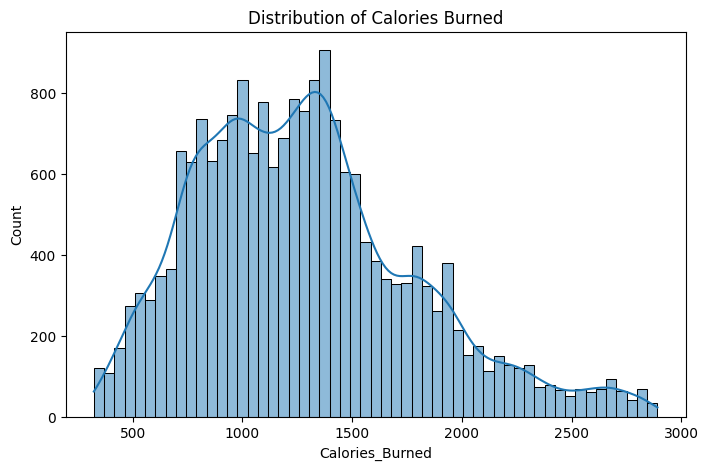

In [186]:
plt.figure(figsize=(8,5))
sns.histplot(df['Calories_Burned'], kde=True)
plt.title('Distribution of Calories Burned')
plt.savefig('calories_dist.png')
plt.show()

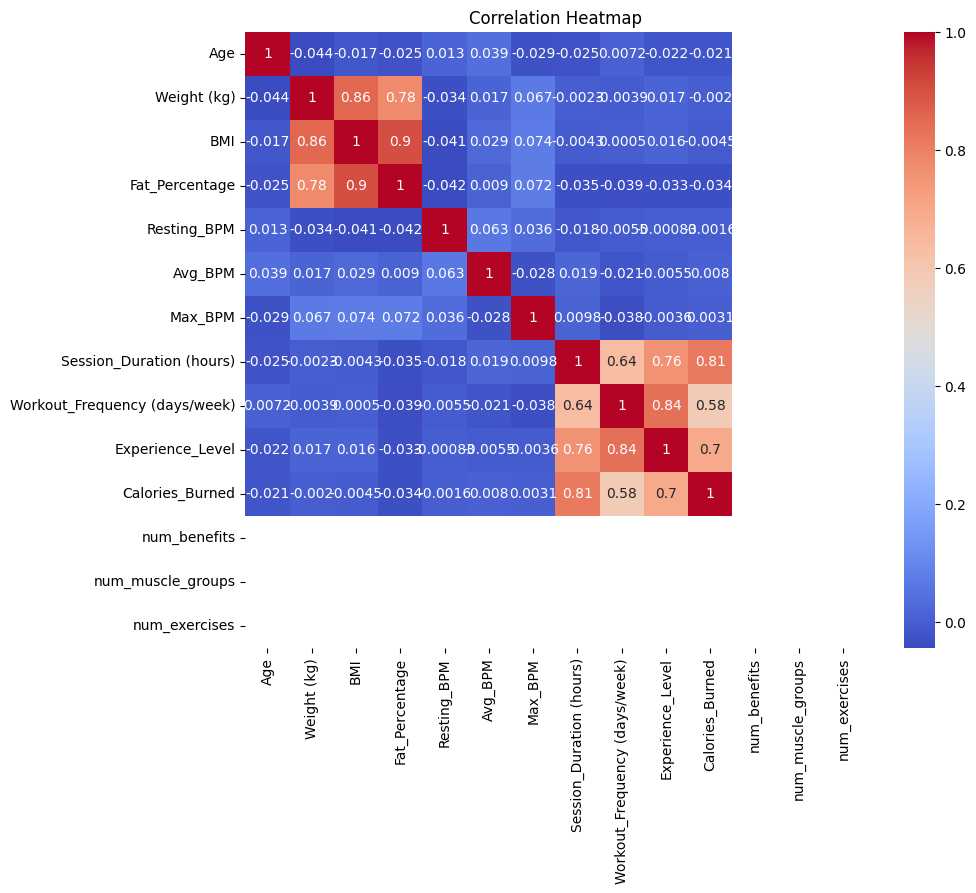

In [187]:
selected_for_corr = ['Age', 'Weight (kg)', 'BMI', 'Fat_Percentage', 'Resting_BPM',
                      'Avg_BPM', 'Max_BPM', 'Session_Duration (hours)', 'Workout_Frequency (days/week)',
                      'Experience_Level', 'Calories_Burned', 'num_benefits', 'num_muscle_groups', 'num_exercises']
df[selected_for_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(df[selected_for_corr].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('corr_heatmap.png')
plt.show()

Enter age: 30
Enter weight (kg): 60
Enter height (m): 1.75
Enter BMI: 22
Enter fat percentage: 20
Enter resting BPM: 24
Enter average BPM: 160
Enter max BPM: 180
Enter session duration (hours): 1.2
Enter workout frequency (days/week): 4
Enter experience level (1-3): 2
Predicted cluster for the input data: 1


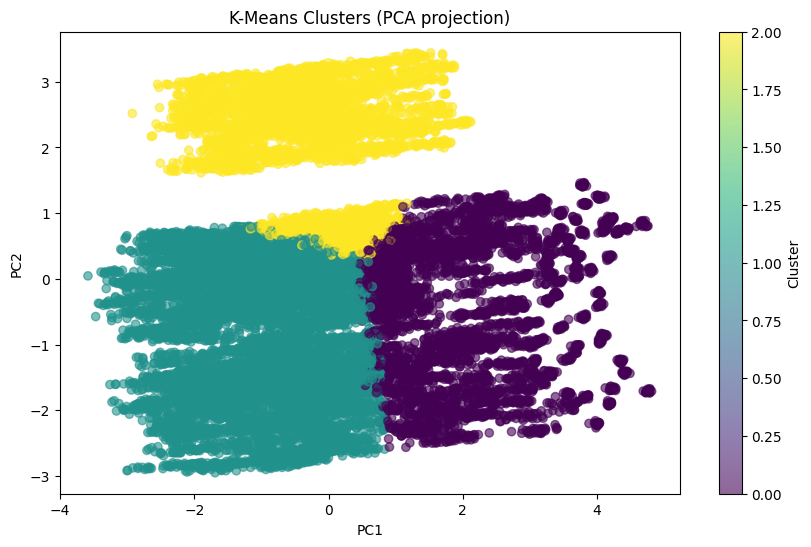

In [198]:

cluster_features = [
    'Age', 'Weight (kg)', 'Height (m)', 'BMI', 'Fat_Percentage', 'Session_Duration (hours)',
    'Resting_BPM', 'Avg_BPM', 'Max_BPM', 'Workout_Frequency (days/week)',
    'Experience_Level'
]

Scaler_cluster = StandardScaler()
x_scaled = Scaler_cluster.fit_transform(df[cluster_features])

kmean_model = KMeans(n_clusters=3, random_state=42)
clusters = kmean_model.fit_predict(x_scaled)

age = float(input("Enter age: "))
weight = float(input("Enter weight (kg): "))
height = float(input("Enter height (m): "))
bmi = float(input("Enter BMI: "))
fat_percentage = float(input("Enter fat percentage: "))
resting_bpm = float(input("Enter resting BPM: "))
avg_bpm = float(input("Enter average BPM: "))
max_bpm = float(input("Enter max BPM: "))
session_duration = float(input("Enter session duration (hours): "))
workout_frequency = float(input("Enter workout frequency (days/week): "))
experience_level = float(input("Enter experience level (1-3): "))

input_data = pd.DataFrame(
    [[age, weight, height, bmi, fat_percentage, session_duration,
      resting_bpm, avg_bpm, max_bpm, workout_frequency, experience_level]],
    columns=cluster_features
)

input_scaled = Scaler_cluster.transform(input_data)

prediction = kmean_model.predict(input_scaled)
print(f'Predicted cluster for the input data: {prediction[0]}')

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)
plt.figure(figsize=(10, 6))
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clusters (PCA projection)')
plt.colorbar(label='Cluster')
plt.show()

with open('Kmean.pkl' , 'wb') as f:
    pickle.dump(kmean_model , f)

In [200]:
X = df[['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'BMI', 'Fat_Percentage',
    'Resting_BPM', 'Avg_BPM', 'Max_BPM', 'Session_Duration (hours)',
    'Workout_Frequency (days/week)', 'Experience_Level', 'Water_Intake (liters)',
    'Daily meals frequency', 'Carbs', 'Proteins', 'Fats', 'Calories',
    'HRR', 'pct_maxHR', 'lean_mass_kg', 'BMI_x_Freq',
    'num_benefits', 'num_muscle_groups', 'num_exercises' , 'Workout_Type_Cardio',
    'Workout_Type_HIIT', 'Workout_Type_Strength', 'Workout_Type_Yoga']]

Y = df[['Calories_Burned']]

X_train , X_test , Y_train , Y_test = train_test_split(X , Y , test_size=0.2 , random_state=42)
X_scaled = StandardScaler()
X_train_scale = X_scaled.fit_transform(X_train)
X_test_scale = X_scaled.transform(X_test)

model = LinearRegression()
model.fit(X_train_scale , Y_train)

y_pred = model.predict(X_test_scale)
mse = mean_squared_error(Y_test , y_pred)
r2 = r2_score(Y_test , y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

# plt.figure(figsize=(10,10))
# plt.scatter(Y_test , y_pred)
# plt.xlabel('Actual Calories Burned')
# plt.ylabel('Predicted Calories Burned')
# plt.title('Actual vs. Predicted Calories Burned')
# plt.show()


# age = float(input("Enter age: "))
# gender = float(input("Enter gender (0=Female, 1=Male): "))
# weight = float(input("Enter weight (kg): "))
# height = float(input("Enter height (m): "))
# bmi = float(input("Enter BMI: "))
# fat_percentage = float(input("Enter fat percentage: "))
# resting_bpm = float(input("Enter resting BPM: "))
# avg_bpm = float(input("Enter average BPM: "))
# max_bpm = float(input("Enter max BPM: "))
# session_duration = float(input("Enter session duration (hours): "))
# workout_frequency = float(input("Enter workout frequency (days/week): "))
# experience_level = float(input("Enter experience level (1-3): "))
# water_intake = float(input("Enter water intake (liters): "))
# daily_meals = float(input("Enter daily meals frequency: "))
# carbs = float(input("Enter carbs (g): "))
# proteins = float(input("Enter proteins (g): "))
# fats = float(input("Enter fats (g): "))
# calories_diet = float(input("Enter calories (dietary intake): "))
# hrr = float(input("Enter HRR (Max BPM - Resting BPM): "))
# pct_maxhr = float(input("Enter pct_maxHR (Avg BPM / Max BPM): "))
# lean_mass = float(input("Enter lean mass (kg): "))
# bmi_x_freq = float(input("Enter BMI × Freq (BMI * workout frequency): "))
# num_benefits = float(input("Enter number of benefits: "))
# num_muscle_groups = float(input("Enter number of muscle groups: "))
# num_exercises = float(input("Enter number of exercises: "))
# workout_type_cardio = float(input("Enter Workout_Type_Cardio (0/1): "))
# workout_type_hiit = float(input("Enter Workout_Type_HIIT (0/1): "))
# workout_type_strength = float(input("Enter Workout_Type_Strength (0/1): "))
# workout_type_yoga = float(input("Enter Workout_Type_Yoga (0/1): "))

# X_input = pd.DataFrame([[age, gender, weight, height, bmi, fat_percentage,
#                      resting_bpm, avg_bpm, max_bpm, session_duration,
#                      workout_frequency, experience_level, water_intake,
#                      daily_meals, carbs, proteins, fats, calories_diet,
#                      hrr, pct_maxhr, lean_mass, bmi_x_freq,
#                      num_benefits, num_muscle_groups, num_exercises,
#                      workout_type_cardio, workout_type_hiit,
#                      workout_type_strength, workout_type_yoga]]
#                    ,
#                    columns=[
#                        'Age', 'Gender', 'Weight (kg)', 'Height (m)', 'BMI', 'Fat_Percentage',
#                        'Resting_BPM', 'Avg_BPM', 'Max_BPM', 'Session_Duration (hours)',
#                        'Workout_Frequency (days/week)', 'Experience_Level', 'Water_Intake (liters)',
#                        'Daily meals frequency', 'Carbs', 'Proteins', 'Fats', 'Calories',
#                        'HRR', 'pct_maxHR', 'lean_mass_kg', 'BMI_x_Freq',
#                        'num_benefits', 'num_muscle_groups', 'num_exercises' , 'Workout_Type_Cardio',
#                        'Workout_Type_HIIT', 'Workout_Type_Strength', 'Workout_Type_Yoga'
#                    ])
# scaler = X_scaled.transform(X_input)
# prediction = model.predict(scaler)
# print("prediction" , prediction[0])

with open('Linear_model.pkl' , 'wb') as f:
    pickle.dump(model , f)

Mean Squared Error: 8257.606010257592
R-squared: 0.9668878478186548


In [ ]:
X = df[['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'BMI', 'Fat_Percentage',
    'Resting_BPM', 'Avg_BPM', 'Max_BPM', 'Session_Duration (hours)',
    'Workout_Frequency (days/week)', 'Experience_Level', 'Water_Intake (liters)',
    'Daily meals frequency', 'Carbs', 'Proteins', 'Fats', 'Calories',
    'HRR', 'pct_maxHR', 'lean_mass_kg', 'BMI_x_Freq',
    'num_benefits', 'num_muscle_groups', 'num_exercises' , 'Workout_Type_Cardio',
    'Workout_Type_HIIT', 'Workout_Type_Strength', 'Workout_Type_Yoga']]

Y = df[['Calories_Burned']]

X_train , X_test , Y_train , Y_test = train_test_split(X , Y , test_size=0.2 , random_state=42)
X_scaled = StandardScaler()
X_train_scale = X_scaled.fit_transform(X_train)
X_test_scale = X_scaled.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scale , Y_train)

y_pred = model.predict(X_test_scale)
mse = mean_squared_error(Y_test , y_pred)
r2 = r2_score(Y_test , y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

# plt.figure(figsize=(10,10))
# plt.scatter(Y_test , y_pred)
# plt.xlabel('Actual Calories Burned')
# plt.ylabel('Predicted Calories Burned')
# plt.title('Actual vs. Predicted Calories Burned')
# plt.show()


age = float(input("Enter age: "))
gender = float(input("Enter gender (0=Female, 1=Male): "))
weight = float(input("Enter weight (kg): "))
height = float(input("Enter height (m): "))
bmi = float(input("Enter BMI: "))
fat_percentage = float(input("Enter fat percentage: "))
resting_bpm = float(input("Enter resting BPM: "))
avg_bpm = float(input("Enter average BPM: "))
max_bpm = float(input("Enter max BPM: "))
session_duration = float(input("Enter session duration (hours): "))
workout_frequency = float(input("Enter workout frequency (days/week): "))
experience_level = float(input("Enter experience level (1-3): "))
water_intake = float(input("Enter water intake (liters): "))
daily_meals = float(input("Enter daily meals frequency: "))
carbs = float(input("Enter carbs (g): "))
proteins = float(input("Enter proteins (g): "))
fats = float(input("Enter fats (g): "))
calories_diet = float(input("Enter calories (dietary intake): "))
hrr = float(input("Enter HRR (Max BPM - Resting BPM): "))
pct_maxhr = float(input("Enter pct_maxHR (Avg BPM / Max BPM): "))
lean_mass = float(input("Enter lean mass (kg): "))
bmi_x_freq = float(input("Enter BMI × Freq (BMI * workout frequency): "))
num_benefits = float(input("Enter number of benefits: "))
num_muscle_groups = float(input("Enter number of muscle groups: "))
num_exercises = float(input("Enter number of exercises: "))
workout_type_cardio = float(input("Enter Workout_Type_Cardio (0/1): "))
workout_type_hiit = float(input("Enter Workout_Type_HIIT (0/1): "))
workout_type_strength = float(input("Enter Workout_Type_Strength (0/1): "))
workout_type_yoga = float(input("Enter Workout_Type_Yoga (0/1): "))

X_input = pd.DataFrame([[age, gender, weight, height, bmi, fat_percentage,
                     resting_bpm, avg_bpm, max_bpm, session_duration,
                     workout_frequency, experience_level, water_intake,
                     daily_meals, carbs, proteins, fats, calories_diet,
                     hrr, pct_maxhr, lean_mass, bmi_x_freq,
                     num_benefits, num_muscle_groups, num_exercises,
                     workout_type_cardio, workout_type_hiit,
                     workout_type_strength, workout_type_yoga]]
                   ,
                   columns=[
                       'Age', 'Gender', 'Weight (kg)', 'Height (m)', 'BMI', 'Fat_Percentage',
                       'Resting_BPM', 'Avg_BPM', 'Max_BPM', 'Session_Duration (hours)',
                       'Workout_Frequency (days/week)', 'Experience_Level', 'Water_Intake (liters)',
                       'Daily meals frequency', 'Carbs', 'Proteins', 'Fats', 'Calories',
                       'HRR', 'pct_maxHR', 'lean_mass_kg', 'BMI_x_Freq',
                       'num_benefits', 'num_muscle_groups', 'num_exercises' , 'Workout_Type_Cardio',
                       'Workout_Type_HIIT', 'Workout_Type_Strength', 'Workout_Type_Yoga'
                   ])
scaler = X_scaled.transform(X_input)
prediction = model.predict(scaler)
print("prediction" , prediction[0])
